In [1]:
import pandas as pd
import json
from pathlib import Path


district_nums = [(8,5), (10,4), (16,5), (20,4), (40,1), (80,1)]
district_mode = ["cambridge", "slate_pl", "slate_bt"]
parties = ["D", "R"]
party_focal = parties[0]
races = ["H", "O"]
race_focal = races[0]
plans = ["000", "200", "400", "600", "800"]
num_profiles_per_district = 100 ### CHANGE

# Might need to run vk_settings_generator again

In [2]:
def avg_prop(dist_res, num_profiles, seats, focal):
    all_entries = [item for unit in dist_res for item in unit]
    # Count how many belong in focal group
    count = sum(1 for item in all_entries if item.startswith(focal))
        
    # Divide by number of profile reps
    prop = count / (num_profiles*seats)
    return(prop)


## Extract results for race

In [ ]:
rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_racial/{dm}/ca_{dn}_districts_{eln}_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            data = json.load(f)
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from eachp plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]

                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # Calculate average proportion across vk election results
                    pr = avg_prop(res_dist, num_profiles_per_district, eln, race_focal)

                    # Add census demographic info from settings file
                    settings_folder = Path(f"./vk_run_settings_racial_turnout/{dn}")
                    settings_filename = f"ca_{dn}_vk_sample_settings_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                    settings_filepath = settings_folder / settings_filename

                    with open(settings_filepath, "r") as g:
                        settings_data = json.load(g)
                        total_hvap = settings_data.get("total_hvap", None)
                        total_vap = settings_data.get("total_vap", None)                        
                        rows.append({"plan": plans[pn],
                                    "total_district_num": dn,
                                    "total_elected": eln,
                                    "dist_num": dist_id,
                                    "mode": dm,
                                    "H_vk_avg_prop": pr,
                                    "H_prop_census": total_hvap/total_vap})

df = pd.DataFrame(rows)
df.head()

[['H2', 'O2', 'H1', 'H3', 'O6'], ['H1', 'H2', 'O7', 'O3', 'O6'], ['H2', 'H3', 'H1', 'O6', 'O7'], ['H1', 'H2', 'O4', 'H3', 'O7'], ['O4', 'H2', 'H3', 'H1', 'O6'], ['H1', 'H3', 'H2', 'O3', 'O5'], ['H1', 'H3', 'H2', 'O3', 'O7'], ['H3', 'H1', 'O7', 'O1', 'O3'], ['H2', 'O3', 'H1', 'O6', 'O7'], ['H1', 'H3', 'O1', 'O7', 'O6'], ['H1', 'O2', 'H3', 'H2', 'O3'], ['H1', 'O6', 'H3', 'O2', 'O7'], ['H2', 'H3', 'H1', 'O4', 'O7'], ['H3', 'H1', 'O2', 'O5', 'O6'], ['H2', 'O3', 'H1', 'H3', 'O2'], ['H3', 'H2', 'O3', 'H1', 'O4'], ['H1', 'H3', 'O6', 'O5', 'H2'], ['H1', 'H3', 'H2', 'O1', 'O3'], ['H1', 'O5', 'H2', 'O6', 'O3'], ['H1', 'H2', 'O7', 'O4', 'H3'], ['H1', 'H3', 'H2', 'O1', 'O5'], ['H3', 'H2', 'H1', 'O3', 'O2'], ['H2', 'H3', 'O3', 'O2', 'H1'], ['H2', 'H3', 'H1', 'O1', 'O3'], ['H1', 'O2', 'H2', 'H3', 'O5'], ['H2', 'H3', 'H1', 'O5', 'O1'], ['O3', 'H2', 'H1', 'H3', 'O2'], ['H3', 'H1', 'O3', 'H2', 'O1'], ['H3', 'H1', 'O3', 'O2', 'H2'], ['H1', 'H3', 'O3', 'O2', 'O5'], ['H1', 'H2', 'O1', 'O4', 'O7'], ['H1', 

,plan,total_district_num,total_elected,dist_num,mode,H_vk_avg_prop,H_prop_census
0,000,8,5,0,cambridge,0.558,0.493650
1,000,8,5,1,cambridge,0.558,0.205215
2,000,8,5,2,cambridge,0.554,0.342776
3,000,8,5,3,cambridge,0.562,0.220756
4,000,8,5,4,cambridge,0.552,0.357692


In [36]:
df.to_csv("Racial_results.csv", index=False) 


## Extract results for partisanship

In [27]:
partisan_rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_partisan_debug/{dm}/ca_{dn}_districts_{eln}_partisan_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            raw_data = json.load(f)
            data = raw_data#[-dn*eln*num_profiles_per_district:]
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from each plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]

                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # Calculate average proportion across vk election results
                    pr = avg_prop(res_dist, num_profiles_per_district, eln, party_focal)

                    # Add census demographic info from settings file
                    settings_folder = Path(f"./vk_run_settings_partisan/{dn}")
                    settings_filename = f"ca_{dn}_vk_sample_settings_partisan_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                    settings_filepath = settings_folder / settings_filename

                    with open(settings_filepath, "r") as g:
                        settings_data = json.load(g)
                        bloc_pr = settings_data.get("bloc_proportions", None)

                        partisan_rows.append({"plan": plans[pn],
                                    "total_district_num": dn,
                                    "total_elected": eln,
                                    "dist_num": dist_id,
                                    "mode": dm,
                                    "Dem_vk_avg_prop": pr,
                                    "Dem_prop_census": bloc_pr["D"]/(bloc_pr["D"]+bloc_pr["R"])})

partisan_df = pd.DataFrame(partisan_rows)
partisan_df.head()

,plan,total_district_num,total_elected,dist_num,mode,Dem_vk_avg_prop,Dem_prop_census
0,000,8,5,0,cambridge,0.562,0.745985
1,000,8,5,1,cambridge,0.564,0.805292
2,000,8,5,2,cambridge,0.548,0.677311
3,000,8,5,3,cambridge,0.556,0.676669
4,000,8,5,4,cambridge,0.566,0.523010


In [28]:
partisan_df.to_csv("Partisan_results.csv", index=False) 

## Histograms of Hispanic seat count for each district x seat configuration

In [25]:
def count_focal_winners(rep_res, focal):
    # Count how many belong in focal group
    all_entries = [item for unit in rep_res for item in unit]
    count = sum(1 for item in all_entries if item.startswith(focal))
    return(count)

In [27]:
rows = []

# For each district division x seats per district
for (dn, eln) in district_nums:

    # For each mode
    for dm in district_mode:
        results_file=Path(f"./vk_ca_election_model_results_racial/{dm}/ca_{dn}_districts_{eln}_winners_for_voter_model_{dm}.json")

        # For each results file, first divide into results from dn different plans
        # Within each plan, each district was repeated by num_profiles_per_district=100
        # Currently assuming order of result file is (plan1,district1)*100, (plan1, district2)*100, ...(plan2, district1)*100

        with open(results_file, "r") as f:
            data = json.load(f)
            plan_data_len = len(data) // len(plans)

            # First split each result file into results from eachp plan
            results_by_plan = [data[i*plan_data_len:(i+1)*plan_data_len] for i in range(len(plans))]

            # For each grouped results by plan
            for pn in range(len(results_by_plan)):
                res_plan = results_by_plan[pn]

                # Split into grouped results by district. Each district should have reps of num_profiles_per_district=100
                results_by_district = [res_plan[i:i+num_profiles_per_district] for i in range(0, len(res_plan), num_profiles_per_district)]
                # For each district
                for dist_id in range(len(results_by_district)):
                    res_dist = results_by_district[dist_id]

                    # For each rep
                    for rep_n in range(len(res_dist)):
                        # Result per rep
                        rep_res = res_dist[rep_n]
                        # Calculate average proportion across vk election results
                        rep_count = count_focal_winners(rep_res, race_focal)
                        
                        # Add census demographic info from settings file
                        settings_folder = Path(f"./vk_run_settings_racial_turnout/{dn}")
                        settings_filename = f"ca_{dn}_vk_sample_settings_district_plan_{plans[pn]}_district_{dist_id:02d}.json"
                        settings_filepath = settings_folder / settings_filename

                        with open(settings_filepath, "r") as g:
                            settings_data = json.load(g)
                            total_hvap = settings_data.get("total_hvap", None)
                            total_vap = settings_data.get("total_vap", None)                        
                            rows.append({"plan": plans[pn],
                                        "total_district_num": dn,
                                        "seats_per_district": eln,
                                        "dist_num": dist_id,
                                        "mode": dm,
                                        "vap": total_vap,
                                        "hvap": total_hvap,
                                        "rep": rep_n,
                                        "H_seats": rep_count})

df_hist = pd.DataFrame(rows)
df_hist.head()

,plan,total_district_num,seats_per_district,dist_num,mode,vap,hvap,rep,H_seats
0,000,8,5,0,cambridge,3689662.0,1821400.0,0,3
1,000,8,5,0,cambridge,3689662.0,1821400.0,1,2
2,000,8,5,0,cambridge,3689662.0,1821400.0,2,3
3,000,8,5,0,cambridge,3689662.0,1821400.0,3,3
4,000,8,5,0,cambridge,3689662.0,1821400.0,4,3


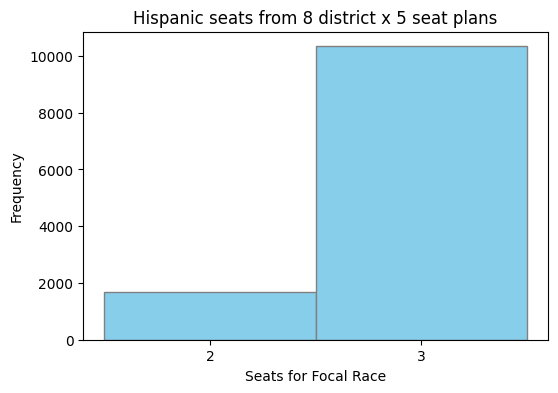

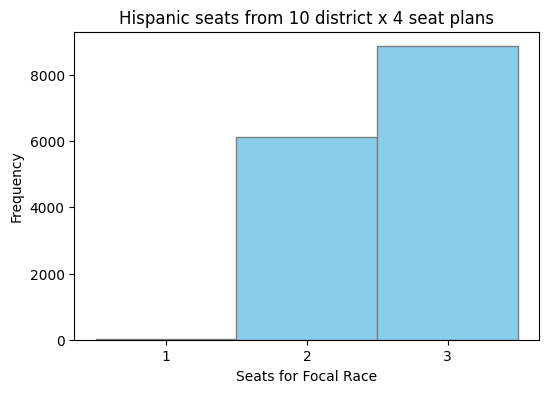

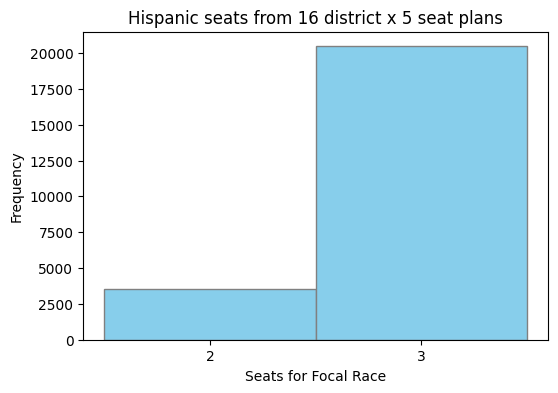

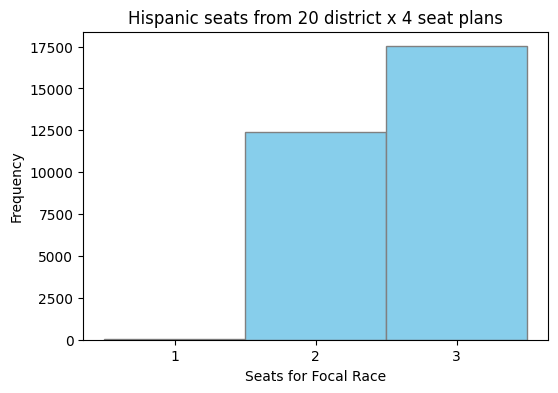

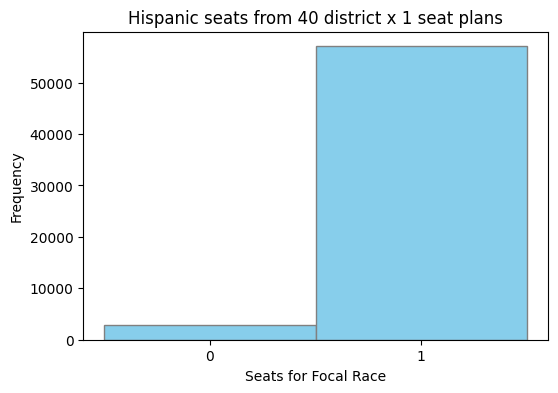

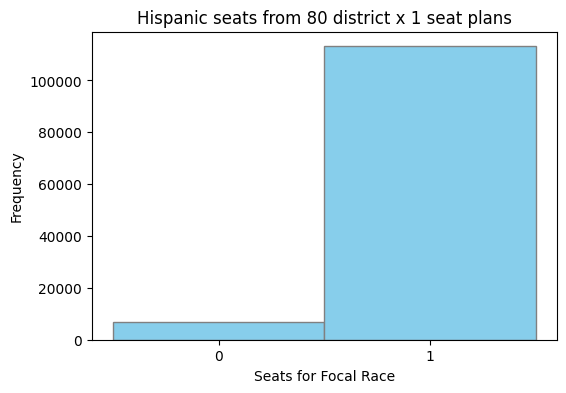

In [31]:
import matplotlib.pyplot as plt

dist_seats = {8:5, 10:4, 16:5, 20:4, 40:1, 80:1}

# Assume your DataFrame is called df
for dn, group in df_hist.groupby("total_district_num"):
    plt.figure(figsize=(6,4))
    plt.hist(group["H_seats"], bins=range(group["H_seats"].min(), group["H_seats"].max()+2), 
             align='left', edgecolor='gray', color='skyblue')
    plt.xticks(range(group["H_seats"].min(), group["H_seats"].max()+1))
    plt.xlabel("Seats for Focal Race")
    plt.ylabel("Frequency")
    plt.title(f"Hispanic seats from {dn} district x {dist_seats[dn]} seat plans")
    plt.show()